In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("energy-history-2026-02-25.csv")
df.columns = df.columns.str.strip().str.lower()
df.head()

,date,time,room,temperature (°c),humidity (%),light (lux),motion
0,23/2/2026,08:32:02,Bedroom,26.9,82.4,6.15,Not Detected
1,23/2/2026,08:31:54,Living Room,27.0,82.5,10.09,Not Detected
2,23/2/2026,08:30:59,Living Room,27.0,82.5,10.26,Not Detected
3,23/2/2026,08:30:57,Bedroom,26.9,82.4,6.37,Not Detected
4,23/2/2026,08:27:59,Living Room,27.0,82.6,10.16,Not Detected


In [3]:
df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"])
df = df.sort_values("timestamp")
df.head()

/tmp/ipython-input-604/2872234701.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"])


,date,time,room,temperature (°c),humidity (%),light (lux),motion,timestamp
1513,22/2/2026,14:16:58,Bedroom,27.7,72.4,85.93,Not Detected,2026-02-22 14:16:58
1512,22/2/2026,14:17:00,Living Room,26.8,76.4,85.89,Not Detected,2026-02-22 14:17:00
1511,22/2/2026,14:17:54,Bedroom,27.3,72.3,85.96,Detected,2026-02-22 14:17:54
1510,22/2/2026,14:17:55,Living Room,26.8,75.3,85.91,Detected,2026-02-22 14:17:55
1509,22/2/2026,14:18:58,Bedroom,27.2,72.7,85.93,Detected,2026-02-22 14:18:58


In [ ]:
df["motion_binary"] = df["motion"].apply(lambda x: 1 if "detected" in x.lower() else 0)

In [ ]:
df["electricity_proxy"] = (
    0.6 * df["light (lux)"] + 0.3 * df["motion_binary"] + 0.1 * df["temperature (°c)"]
)

In [6]:
df["hour"] = df["timestamp"].dt.hour

In [7]:
hourly_consumption = df.groupby("hour")["electricity_proxy"].mean()
hourly_consumption

,electricity_proxy
hour,
0,56.663684
1,46.478128
2,7.794388
3,7.862245
4,7.885583
5,7.811176
6,7.807735
7,7.878577
8,7.912033


In [17]:
low_energy_hours = hourly_consumption.nsmallest(7)
print("Lowest Energy Consumption Hours:")
print(low_energy_hours)

Lowest Energy Consumption Hours:
hour
2    7.794388
6    7.807735
5    7.811176
3    7.862245
7    7.878577
4    7.885583
8    7.912033
Name: electricity_proxy, dtype: float64


In [18]:
rolling_6hr = hourly_consumption.rolling(6).mean()
best_start_hour = rolling_6hr.idxmin()
print(f"Lowest continuous 6-hour window starts at: {best_start_hour}:00")
print(f"Window: {best_start_hour}:00 to {(best_start_hour+6)%24}:00")

Lowest continuous 6-hour window starts at: 7:00
Window: 7:00 to 13:00


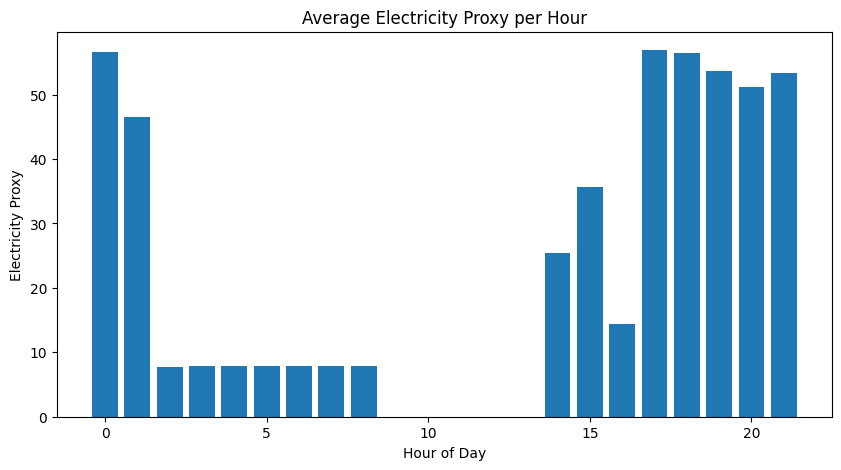

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(hourly_consumption.index, hourly_consumption.values)
plt.title("Average Electricity Proxy per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Electricity Proxy")
plt.show()

In [ ]:
import joblib

low_energy_list = [
    best_start_hour,
    (best_start_hour + 1) % 24,
    (best_start_hour + 2) % 24,
]
joblib.dump(low_energy_list, "low_energy_hours.pkl")
print("Saved low_energy_hours.pkl")

Saved low_energy_hours.pkl
